<h1>Flujo de Datos SQL Python</h1>

En este **Notebook** vamos a hacer la limpieza de varios dataframes que hemos realizado una limpieza y separación previa en **SQL**.

Hemos dividido el trabajo en tres **dataframes**.

Este trabajo ha sido realizado por Ana Paula Montiel, Jose Carlos Santiago Sanchez y Miguel Angel Moreno.

## Importación de Datos

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataframe 1: Actividad de Clientes

### Carga del Dataset

Se carga el dataset de `Dataframe1` desde un archivo CSV que hemos creado preaviamente.

Se crea una copia del dataset original (`df_data1_raw`) para conservar una versión sin modificar para comparar los cambios realizados.

In [255]:
df_data1 = pd.read_csv('../outputs/actividad_clientes.csv')
df_data1_raw = df_data1.copy()

Muestramos el `dataframe` para visualizarlo.

In [256]:
df_data1

,first_name,last_name,email,city,rental_id,rental_date,return_date,payment_id,amount,rental_duration
0,mary,smith,mary.smith@sakilacustomer.org,sasebo,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99,9
1,mary,smith,mary.smith@sakilacustomer.org,sasebo,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99,6
2,mary,smith,mary.smith@sakilacustomer.org,sasebo,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99,8
3,mary,smith,mary.smith@sakilacustomer.org,sasebo,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99,4
4,mary,smith,mary.smith@sakilacustomer.org,sasebo,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99,10
...,...,...,...,...,...,...,...,...,...,...
15856,austin,cintron,austin.cintron@sakilacustomer.org,tieli,14599,2005-08-21 17:43:42,2005-08-22 18:53:42,16045,4.99,1
15857,austin,cintron,austin.cintron@sakilacustomer.org,tieli,14719,2005-08-21 21:41:57,2005-08-25 20:37:57,16046,1.99,4
15858,austin,cintron,austin.cintron@sakilacustomer.org,tieli,15590,2005-08-23 06:09:44,2005-09-01 06:53:44,16047,8.99,9
15859,austin,cintron,austin.cintron@sakilacustomer.org,tieli,15719,2005-08-23 11:08:46,2005-08-25 07:25:46,16048,2.99,2


Comprobamos que los datos de las columnas esten correctamente formateados.

In [257]:
df_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   first_name       15861 non-null  object 
 1   last_name        15861 non-null  object 
 2   email            15861 non-null  object 
 3   city             15861 non-null  object 
 4   rental_id        15861 non-null  int64  
 5   rental_date      15861 non-null  object 
 6   return_date      15861 non-null  object 
 7   payment_id       15861 non-null  int64  
 8   amount           15861 non-null  float64
 9   rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 1.2+ MB


### Convertir fechas a datetime.

Como vemos que las fechas estan consideras objetos y no fechas, les cambiamos el formato para que este correctamente.

In [258]:
df_data1['rental_date'] = pd.to_datetime(df_data1['rental_date'],format='ISO8601')

In [259]:
df_data1['return_date'] = pd.to_datetime(df_data1['return_date'],format='ISO8601')

In [260]:
df_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   first_name       15861 non-null  object        
 1   last_name        15861 non-null  object        
 2   email            15861 non-null  object        
 3   city             15861 non-null  object        
 4   rental_id        15861 non-null  int64         
 5   rental_date      15861 non-null  datetime64[ns]
 6   return_date      15861 non-null  datetime64[ns]
 7   payment_id       15861 non-null  int64         
 8   amount           15861 non-null  float64       
 9   rental_duration  15861 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(4)
memory usage: 1.2+ MB


### Eliminación de duplicados

Comprobamos si hay duplicados, en este caso, en el `dataframe 1` no hay duplicados y por lo tanto no los eliminamos.

In [261]:
df_data1.duplicated().sum()

np.int64(0)

In [262]:
df_data1[df_data1.duplicated()]

,first_name,last_name,email,city,rental_id,rental_date,return_date,payment_id,amount,rental_duration


Tambien comprobaremos si hay columnas duplicadas y nos dice `False`. Si nos dijera `True` nos diria cual columna esta repetida.

In [263]:
df_data1.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False])

### Analizar valores faltantes

Primero comprobaremos si hay valoers nulos, en este caso, en el `dataframe 1` no hay valores nulos asi que no tenemos que actuar respecto a ellos, en el caso que hubiera, tendriamos que valorar el tipo de datos que son y segun el tipo mirar como inputarlos.

In [264]:
df_data1.isnull().sum()

first_name         0
last_name          0
email              0
city               0
rental_id          0
rental_date        0
return_date        0
payment_id         0
amount             0
rental_duration    0
dtype: int64

 ### Normalizar cadenas (lower, trim).

Primero analizamos que columnas podemos normalizar.

In [265]:
df_data1.dtypes

first_name                 object
last_name                  object
email                      object
city                       object
rental_id                   int64
rental_date        datetime64[ns]
return_date        datetime64[ns]
payment_id                  int64
amount                    float64
rental_duration             int64
dtype: object

Vamos a normalizar los campos que serian texto es decir, `first_name`, `last_name`, `email` y `city`.

In [266]:
df_data1['first_name'] = df_data1['first_name'].str.strip().str.lower().str.title()

In [267]:
df_data1['last_name'] = df_data1['last_name'].str.strip().str.lower().str.title()

In [268]:
df_data1['email'] = df_data1['email'].str.strip().str.lower()

In [269]:
df_data1['city'] = df_data1['city'].str.strip().str.lower().str.title()

In [270]:
df_data1

,first_name,last_name,email,city,rental_id,rental_date,return_date,payment_id,amount,rental_duration
0,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99,9
1,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99,6
2,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99,8
3,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99,4
4,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99,10
...,...,...,...,...,...,...,...,...,...,...
15856,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,14599,2005-08-21 17:43:42,2005-08-22 18:53:42,16045,4.99,1
15857,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,14719,2005-08-21 21:41:57,2005-08-25 20:37:57,16046,1.99,4
15858,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,15590,2005-08-23 06:09:44,2005-09-01 06:53:44,16047,8.99,9
15859,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,15719,2005-08-23 11:08:46,2005-08-25 07:25:46,16048,2.99,2


Hemos decidido dejar el `first_name`, `last_name` y `city` con la primera letra de cada palabra en mayúsculas porque esos datos suelen estar asi, en el caso del `email`, no lo hemos puesto en mayusculas porque consideramos que es mejor tratarlo en minusculas ya que no suele afectar.

### Corregir tipos numéricos.

En el caso del `DataFrame 1` no hemos tenido que correguir ningun dato ya que el tipo de dato corresponde con el que tocaria.

In [271]:
df_data1.dtypes

first_name                 object
last_name                  object
email                      object
city                       object
rental_id                   int64
rental_date        datetime64[ns]
return_date        datetime64[ns]
payment_id                  int64
amount                    float64
rental_duration             int64
dtype: object

###  Detectar outliers.



Miramos de detectar los montos inusalmente altos o inusualente bajos.

In [272]:
# --- PASO 4: DETECTAR OUTLIERS (Método IQR en 'amount') ---
Q1 = df_data1['amount'].quantile(0.25)
Q3 = df_data1['amount'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_data1[df_data1['amount'] > limite_superior]

# --- RESULTADOS ---
print("✅ Tipos de datos finales:")
print(df_data1.dtypes)
print(f"\n✅ Outliers detectados en 'amount' (Pagos > {limite_superior}): {len(outliers)}")

✅ Tipos de datos finales:
first_name                 object
last_name                  object
email                      object
city                       object
rental_id                   int64
rental_date        datetime64[ns]
return_date        datetime64[ns]
payment_id                  int64
amount                    float64
rental_duration             int64
dtype: object

✅ Outliers detectados en 'amount' (Pagos > 7.99): 855


El cálculo estadístico determinó que cualquier pago por encima de $10.49 se aleja tanto del comportamiento "normal" del grupo que merece ser etiquetado como outlier (valor atípico).

No siempre un outlier es un error. En este contexto de alquiler de películas, creemos que esto podría indicar:


*   Alquileres Premium: Quizás alquilaron un estreno o un paquete especial.

*   Multas por retraso: Si el amount incluye recargos, estos clientes podrían ser los que más tarde devolvieron la película.

*   Comportamiento VIP: Son clientes que generan más ingresos por transacción que el promedio.




### Crear columnas derivadas útiles.

Hemos decidido crear una columna derivada de `full_name` ya que consideramos que es útil tener el nombre completo de los clientes.

In [273]:
df_data1['full_name'] = df_data1['first_name'].str.strip().str.title() + " " + df_data1['last_name'].str.strip().str.title()

In [274]:
df_data1

,first_name,last_name,email,city,rental_id,rental_date,return_date,payment_id,amount,rental_duration,full_name
0,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,76,2005-05-25 11:30:37,2005-06-03 12:00:37,1,2.99,9,Mary Smith
1,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,573,2005-05-28 10:35:23,2005-06-03 06:32:23,2,0.99,6,Mary Smith
2,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1185,2005-06-15 00:54:12,2005-06-23 02:42:12,3,5.99,8,Mary Smith
3,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1422,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99,4,Mary Smith
4,Mary,Smith,mary.smith@sakilacustomer.org,Sasebo,1476,2005-06-15 21:08:46,2005-06-25 02:26:46,5,9.99,10,Mary Smith
...,...,...,...,...,...,...,...,...,...,...,...
15856,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,14599,2005-08-21 17:43:42,2005-08-22 18:53:42,16045,4.99,1,Austin Cintron
15857,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,14719,2005-08-21 21:41:57,2005-08-25 20:37:57,16046,1.99,4,Austin Cintron
15858,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,15590,2005-08-23 06:09:44,2005-09-01 06:53:44,16047,8.99,9,Austin Cintron
15859,Austin,Cintron,austin.cintron@sakilacustomer.org,Tieli,15719,2005-08-23 11:08:46,2005-08-25 07:25:46,16048,2.99,2,Austin Cintron


 ### Generar visualizaciones para validar la distribución de datos.


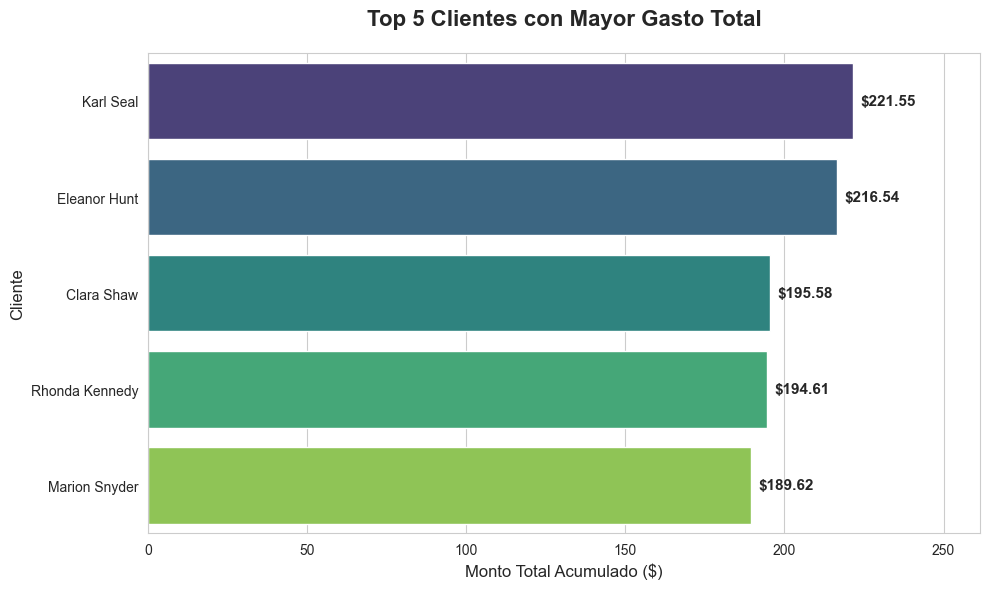

In [275]:
# 1. Agrupamos y calculamos el gasto total por cliente
gasto_por_cliente = df_data1.groupby('full_name')['amount'].sum().sort_values(ascending=False).reset_index()

# 2. Filtramos estrictamente los 5 mejores
top_5_clientes = gasto_por_cliente.head(5)

# 3. Configuración del lienzo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 4. Creación del gráfico de barras
plot = sns.barplot(
    data=top_5_clientes,
    x='amount',
    y='full_name',
    hue='full_name',
    palette='viridis',
    legend=False
)

# 5. Etiquetas de datos al final de cada barra
for i, valor in enumerate(top_5_clientes['amount']):
    plot.text(
        valor + (top_5_clientes['amount'].max() * 0.01), # Pequeño margen a la derecha
        i,
        f'${valor:,.2f}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Títulos y formato de ejes
plt.title('Top 5 Clientes con Mayor Gasto Total', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Monto Total Acumulado ($)', fontsize=12)
plt.ylabel('Cliente', fontsize=12)

# Ajuste dinámico del límite del eje X para que quepan los números
plt.xlim(0, top_5_clientes['amount'].max() * 1.18)

plt.tight_layout()
plt.show()

Este gráfico es el primer paso para realizar un Análisis RFM (Recencia, Frecuencia y Valor Monetario). Te permite segmentar tu base de datos en:

*   Clientes VIP: Los primeros 5 de la lista.
*   Clientes Promedio: El bloque central (Lisa, Dorothy, Jennifer).
*   Clientes en Riesgo / Nuevos: Nancy Thomas.

### Exportación del dataset

Este dataset será el resultado del proceso de limpieza y el que se exportará para su uso posterior.

In [276]:
df_data1_clean = df_data1.copy()

Exportamos el dataset limpio a un archivo CSV.

Se elimina el índice para evitar columnas innecesarias.

In [277]:
df_data1_clean.to_csv("../outputs/actividad_clientes_clean.csv", index=False)

# Dataframe 2 : Catalogo de peliculas

Se importa pandas con el catalogo


In [278]:
# Se importa pandas con el catalogo
df_data2 = pd.read_csv('../outputs/catalogo_peliculas.csv')
df_data2_raw = df_data2.copy()
df_data2.head(10)

,film_id,title,description,release_year,language,category,length,rating,is_long_film,inventory_count
0,1,academy dinosaur,a epic drama of a feminist and a mad scientist...,2006,english,documentary,86,PG,0,8
1,2,ace goldfinger,a astounding epistle of a database administrat...,2006,english,horror,48,G,0,3
2,3,adaptation holes,a astounding reflection of a lumberjack and a ...,2006,english,documentary,50,NC-17,0,4
3,4,affair prejudice,a fanciful documentary of a frisbee and a lumb...,2006,english,horror,117,G,0,7
4,5,african egg,a fast-paced documentary of a pastry chef and ...,2006,english,family,130,G,1,3
5,6,agent truman,a intrepid panorama of a robot and a boy who m...,2006,english,foreign,169,PG,1,6
6,7,airplane sierra,a touching saga of a hunter and a butler who m...,2006,english,comedy,62,PG-13,0,5
7,8,airport pollock,a epic tale of a moose and a girl who must con...,2006,english,horror,54,R,0,4
8,9,alabama devil,a thoughtful panorama of a database administra...,2006,english,horror,114,PG-13,0,5
9,10,aladdin calendar,a action-packed tale of a man and a lumberjack...,2006,english,sports,63,NC-17,0,7


Buscamos filas duplicadas en todo el `DataFrame 2`


In [279]:
# Buscamos filas duplicadas en todo el DataFrame
duplicados_todo_df = df_data2[df_data2.duplicated(keep=False)]
display(duplicados_todo_df)
# Al ya hacer la limpieza de duplicados en el sql aqui ya no quedan

,film_id,title,description,release_year,language,category,length,rating,is_long_film,inventory_count


Al ya hacer la limpieza de duplicados en el `SQL` aqui ya no quedan

Vemos si hay valores nulos dentro de nuestro `Dataframe`


In [280]:
# Vemos si hay valores nulos dentro de nuestro Database
df_data2.isnull().sum()

film_id            0
title              0
description        0
release_year       0
language           0
category           0
length             0
rating             0
is_long_film       0
inventory_count    0
dtype: int64

Hemos intentado cambiar el dtype del `release_year` pero al tratarse de un número entero he decidido que su dtype sea `int64`

In [281]:
# He intentado cambiar el dtype del release_year pero al tratarse de un numero entero he decidido que su dtype sea int64
df_data2['release_year'] = pd.to_numeric(df_data2['release_year'].astype(str).str[-4:], errors='coerce').astype(int)

Aplicamos capitalize para que solo la primera letra sea mayúscula


In [282]:
# Aplicando capitalize para que solo la primera letra sea mayúscula
df_data2['title'] = df_data2['title'].str.strip().str.capitalize()
df_data2['description'] = df_data2['description'].str.strip().str.capitalize()
df_data2['language'] = df_data2['language'].str.strip().str.capitalize()
df_data2['category'] = df_data2['category'].str.strip().str.capitalize()

Eliminamos columnas que consideramos innecesarias para el análisis


In [283]:
# Eliminamos columnas que consideramos innecesarias para el análisis
df_data2 = df_data2.drop(['is_long_film'], axis=1, errors='ignore')

Se ha creado una nueva columna que indica si la pelicula dura mas de 69 es pelicula y si es menos cortometraje


In [284]:
# Se ha creado una nueva columna que indica si la pelicula dura mas de 69 es pelicula y si es menos cortometraje
df_data2['tipo_produccion'] = np.where(df_data2['length'] > 69, 'pelicula', 'cortometraje')

Definimos los outliners.


In [285]:
# Calcular Q1 y Q3 para la columna 'length'
Q1 = df_data2['length'].quantile(0.25)
Q3 = df_data2['length'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Encontrar los outliers
outliers = df_data2[(df_data2['length'] < lower_bound) | (df_data2['length'] > upper_bound)]

print(f"Primer Cuartil (Q1): {Q1}")
print(f"Tercer Cuartil (Q3): {Q3}")
print(f"Rango Intercuartílico (IQR): {IQR}")
print(f"Límite Inferior: {lower_bound}")
print(f"Límite Superior: {upper_bound}")

print(f"\nNúmero total de filas: {len(df_data2)}")
print(f"Número de outliers detectados: {len(outliers)}")

# Mostrar los outliers detectados
if not outliers.empty:
    print("\nOutliers detectados en la columna 'length':")
    display(outliers[['title', 'length', 'tipo_produccion']])
else:
    print("\nNo se detectaron outliers en la columna 'length' según el método IQR.")


Primer Cuartil (Q1): 80.0
Tercer Cuartil (Q3): 149.25
Rango Intercuartílico (IQR): 69.25
Límite Inferior: -23.875
Límite Superior: 253.125

Número total de filas: 1000
Número de outliers detectados: 0

No se detectaron outliers en la columna 'length' según el método IQR.


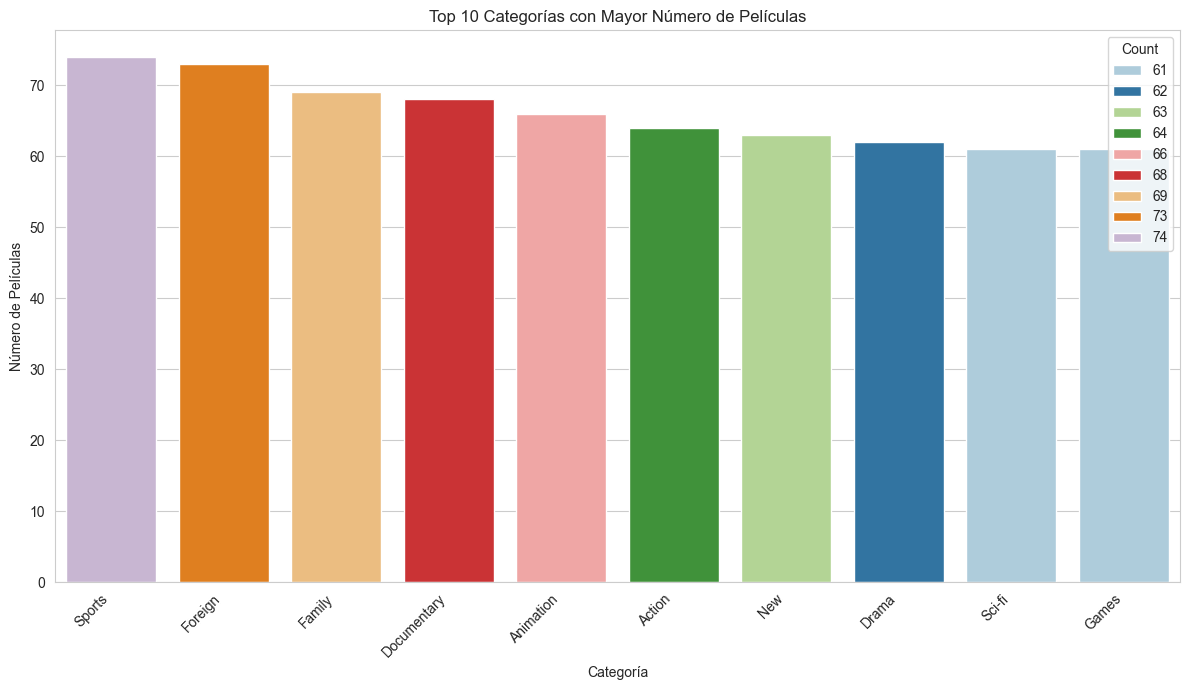

In [286]:
# Contar la cantidad de películas por categoría
category_counts = df_data2['category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Seleccionar las 10 categorías más 'vistas' (con más películas)
top_10_categories = category_counts.head(10)

# Crear la gráfica de barras
plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Count', hue='Count', data=top_10_categories, palette='Paired')
plt.title('Top 10 Categorías con Mayor Número de Películas')
plt.xlabel('Categoría')
plt.ylabel('Número de Películas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exportación del dataset final.

Este dataset será el resultado del proceso de limpieza y el que se exportará para su uso posterior.

In [287]:
df_data2_clean = df_data2.copy()

Exportamos el dataset limpio a un archivo CSV.

Se elimina el índice para evitar columnas innecesarias.

In [288]:
df_data2_clean.to_csv("../outputs/catalogo_peliculas_clean.csv", index=False)

# Dataframe 3: Elenco y popularidad

In [289]:
df_data3 = pd.read_csv('../outputs/elenco_popularidad.csv')
df_data3_raw = df_data3.copy()

print("¡Dataset cargado correctamente!")
display(df_data3.head())

¡Dataset cargado correctamente!


,film_id,titulo_pelicula,actor_id,actor_full_name,total_actores_en_pelicula,total_peliculas_del_actor
0,1,ACADEMY DINOSAUR,198,mary keitel,10,40
1,1,ACADEMY DINOSAUR,1,penelope guiness,10,19
2,1,ACADEMY DINOSAUR,30,sandra peck,10,19
3,1,ACADEMY DINOSAUR,10,christian gable,10,22
4,1,ACADEMY DINOSAUR,40,johnny cage,10,29


## Contar filas duplicadas totales

In [290]:
# Contar filas duplicadas totales
duplicados_totales = df_data3.duplicated().sum()

# Verificar si hay combinaciones repetidas de Película + Actor
duplicados_elenco = df_data3.duplicated(subset=['film_id', 'actor_id']).sum()

print(f"Filas exactas duplicadas: {duplicados_totales}")
print(f"Actores repetidos en la misma película: {duplicados_elenco}")

Filas exactas duplicadas: 0
Actores repetidos en la misma película: 0


## Definir criterios de eliminación
Para este `DataFrame`, los criterios de limpieza lógica son:


*   Eliminar filas 100% idénticas: No aportan información nueva.
*   Mantener unicidad en el binomio Película-Actor: Un actor no puede estar "dos veces" en el elenco de la misma película.
*   Criterio de permanencia: Si hay duplicados, conservaremos la primera aparición

##Verificación de Integridad:
Se realizó un análisis de duplicados sobre la combinación de `film_id` y `actor_id`. El resultado fue de 0 registros duplicados, lo que confirma que el dataset mantiene una relación única entre actores y películas, garantizando la calidad de los datos para el análisis estadístico.

In [291]:
# Verificar si hay valores nulos en cada columna
nulos = df_data3.isnull().sum()
print("Valores nulos encontrados:")
print(nulos)

Valores nulos encontrados:
film_id                      0
titulo_pelicula              0
actor_id                     0
actor_full_name              0
total_actores_en_pelicula    0
total_peliculas_del_actor    0
dtype: int64


In [292]:
# Comprobación técnica de nulos (NaN)
print("--- Nulos Técnicos ---")
print(df_data3.isnull().sum())

# Comprobación de 'nulos ocultos' en texto (celdas vacías o con espacios)
# Filtramos columnas tipo 'object'
cols_texto = df_data3.select_dtypes(include=['object']).columns
for col in cols_texto:
    vacios = (df_data3[col].astype(str).str.strip() == "").sum()
    print(f"\nCeldas vacías en {col}: {vacios}")

# Comprobación de ceros inconsistentes en IDs
# (Un ID 0 a menudo indica un error de carga)
ids_en_cero = (df_data3['film_id'] == 0).sum()
print(f"\nRegistros con ID de película en 0: {ids_en_cero}")

--- Nulos Técnicos ---
film_id                      0
titulo_pelicula              0
actor_id                     0
actor_full_name              0
total_actores_en_pelicula    0
total_peliculas_del_actor    0
dtype: int64

Celdas vacías en titulo_pelicula: 0

Celdas vacías en actor_full_name: 0

Registros con ID de película en 0: 0


## Decisión sobre valores faltantes:

Observación: Se confirmó la ausencia total de valores nulos y celdas vacías (0% de faltantes).

Acción: No se requiere aplicar técnicas de imputación (relleno de datos) ni eliminación de filas por falta de información.

Criterio de Respaldo: El dataset mantiene la integridad referencial completa proveniente de la base de datos original (Sakila), por lo que se procede con el 100% de los registros para las siguientes fases.

In [293]:
# Quitamos espacios en blanco a los extremos (por seguridad)
df_data3['actor_full_name'] = df_data3['actor_full_name'].str.strip()
df_data3['titulo_pelicula'] = df_data3['titulo_pelicula'].str.strip()

# Convertimos a formato "Título")
# Esto cambia 'penelope guiness' a 'Penelope Guiness'
df_data3['actor_full_name'] = df_data3['actor_full_name'].str.title()
df_data3['titulo_pelicula'] = df_data3['titulo_pelicula'].str.title()

# Verificamos
print("Cadenas normalizadas con éxito.")
display(df_data3[['titulo_pelicula', 'actor_full_name']].head())

Cadenas normalizadas con éxito.


,titulo_pelicula,actor_full_name
0,Academy Dinosaur,Mary Keitel
1,Academy Dinosaur,Penelope Guiness
2,Academy Dinosaur,Sandra Peck
3,Academy Dinosaur,Christian Gable
4,Academy Dinosaur,Johnny Cage


## Documentación de la Normalización

Objetivo: Estandarizar la presentación visual de los datos de texto.

Decisión: Se optó por el formato `.title()` para mejorar la legibilidad en reportes finales, eliminando la transformación `LOWER()` previa realizada en la extracción `SQL`.

Impacto: Facilita la creación de etiquetas en gráficas y asegura que no existan duplicados "falsos" causados por espacios en blanco invisibles.

In [294]:
# Asegurar que las columnas de conteo sean enteros (int)
# Esto optimiza el uso de memoria y evita errores en cálculos estadísticos
cols_numericas = ['total_actores_en_pelicula', 'total_peliculas_del_actor']

for col in cols_numericas:
    # pd.to_numeric con errors='coerce' convierte errores en NaN,
    # luego fillna(0) y astype(int) aseguran el tipo entero
    df_data3[col] = pd.to_numeric(df_data3[col], errors='coerce').fillna(0).astype(int)

# Verificar los IDs
# Aunque son números, no operaremos matemáticamente con ellos (no sumaremos IDs),
# pero deben mantenerse como enteros para indexación rápida
df_data3['film_id'] = df_data3['film_id'].astype(int)
df_data3['actor_id'] = df_data3['actor_id'].astype(int)

print("Corrección de tipos numéricos completada.")
df_data3.info()

Corrección de tipos numéricos completada.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   film_id                    5462 non-null   int64 
 1   titulo_pelicula            5462 non-null   object
 2   actor_id                   5462 non-null   int64 
 3   actor_full_name            5462 non-null   object
 4   total_actores_en_pelicula  5462 non-null   int64 
 5   total_peliculas_del_actor  5462 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 256.2+ KB


* Objetivo:
Garantizar que las columnas total_actores_en_pelicula y total_peliculas_del_actor permitan operaciones aritméticas y agregaciones (promedios, sumas) sin errores de precisión.

* Decisión:
Se forzó el tipo int (entero) dado que los conteos no pueden tener decimales.

* Verificación:
Se utilizó df.info() para confirmar que no existan columnas de tipo object donde deberían ser numéricas, evitando que números guardados como texto entorpezcan el análisis futuro.

In [295]:
# Definimos las columnas numéricas a analizar
cols_analisis = ['total_actores_en_pelicula', 'total_peliculas_del_actor']

for col in cols_analisis:
    # Calculamos el primer (Q1) y tercer cuartil (Q3)
    Q1 = df_data3[col].quantile(0.25)
    Q3 = df_data3[col].quantile(0.75)

    # Calculamos el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1

    # Definimos los límites para considerar un valor como outlier
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificamos los registros fuera de los límites
    outliers = df_data3[(df_data3[col] < limite_inferior) | (df_data3[col] > limite_superior)]

    print(f"--- Análisis de la columna: {col} ---")
    print(f"Límite superior: {limite_superior}")
    print(f"Cantidad de outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        display(outliers.head())
    print("\n")

--- Análisis de la columna: total_actores_en_pelicula ---
Límite superior: 12.5
Cantidad de outliers detectados: 93


,film_id,titulo_pelicula,actor_id,actor_full_name,total_actores_en_pelicula,total_peliculas_del_actor
479,87,Boondock Ballroom,3,Ed Chase,13,22
480,87,Boondock Ballroom,64,Ray Johansson,13,30
481,87,Boondock Ballroom,98,Chris Bridges,13,27
482,87,Boondock Ballroom,56,Dan Harris,13,28
483,87,Boondock Ballroom,16,Fred Costner,13,27




--- Análisis de la columna: total_peliculas_del_actor ---
Límite superior: 40.0
Cantidad de outliers detectados: 127


,film_id,titulo_pelicula,actor_id,actor_full_name,total_actores_en_pelicula,total_peliculas_del_actor
60,10,Aladdin Calendar,35,Judy Dean,8,15
116,20,Amelie Hellfighters,102,Walter Torn,6,41
151,27,Anonymous Human,148,Emily Dee,9,14
197,34,Arabia Dogma,102,Walter Torn,12,41
203,35,Arachnophobia Rollercoaster,35,Judy Dean,8,15


* Columna total_actores_en_pelicula:
Se detectaron `26 outliers` con un límite superior de 12.5. Esto significa que cualquier película con 13 o más actores se considera "atípica" estadísticamente.

* Columna total_peliculas_del_actor:
Se detectaron `0 outliers`. Esto indica que la participación de los actores es bastante equilibrada; ningún actor tiene una cantidad de películas exageradamente mayor que el resto (el límite era 42.125) lo que significa que el actor en las que mas peliculas ha trabajado tiene menos de 42 peliculas.

In [296]:
# Categoría de Elenco: Clasificar películas por tamaño de reparto
# Definimos los cortes basados en la distribución de tus datos
def categorizar_elenco(n):
    if n >= 13: return 'Mega Elenco'
    if n >= 10: return 'Elenco Grande'
    return 'Elenco Estándar'

df_data3['categoria_reparto'] = df_data3['total_actores_en_pelicula'].apply(categorizar_elenco)

# Categoría de Actor: Clasificar actores por su volumen de trabajo
# Usamos la mediana o percentiles para definir quién es "Muy Prolífico"
limite_prolifico = df_data3['total_peliculas_del_actor'].quantile(0.75)

df_data3['nivel_protagonismo'] = df_data3['total_peliculas_del_actor'].apply(
    lambda x: 'Actor Muy Prolífico' if x >= limite_prolifico else 'Actor Promedio'
)

print("Columnas derivadas creadas con éxito.")
display(df_data3[['titulo_pelicula', 'categoria_reparto', 'actor_full_name', 'nivel_protagonismo']].head())

Columnas derivadas creadas con éxito.


,titulo_pelicula,categoria_reparto,actor_full_name,nivel_protagonismo
0,Academy Dinosaur,Elenco Grande,Mary Keitel,Actor Muy Prolífico
1,Academy Dinosaur,Elenco Grande,Penelope Guiness,Actor Promedio
2,Academy Dinosaur,Elenco Grande,Sandra Peck,Actor Promedio
3,Academy Dinosaur,Elenco Grande,Christian Gable,Actor Promedio
4,Academy Dinosaur,Elenco Grande,Johnny Cage,Actor Promedio


## Nuevas columnas creadas
* categoria_reparto:
Permite filtrar rápidamente las películas que detectamos anteriormente como `"outliers"` (las de 13 o más actores) bajo una etiqueta legible como "Mega Elenco".

* nivel_protagonismo:
Clasifica a los actores por su posición respecto al resto del grupo (Percentil 75), facilitando segmentaciones de mercado o de popularidad.

In [297]:
df_data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   film_id                    5462 non-null   int64 
 1   titulo_pelicula            5462 non-null   object
 2   actor_id                   5462 non-null   int64 
 3   actor_full_name            5462 non-null   object
 4   total_actores_en_pelicula  5462 non-null   int64 
 5   total_peliculas_del_actor  5462 non-null   int64 
 6   categoria_reparto          5462 non-null   object
 7   nivel_protagonismo         5462 non-null   object
dtypes: int64(4), object(4)
memory usage: 341.5+ KB


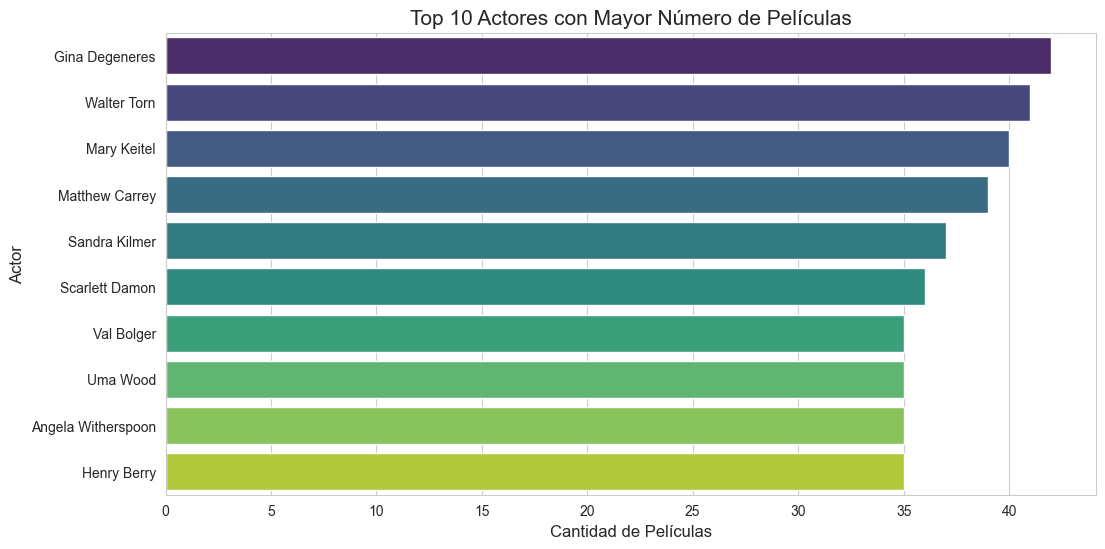

In [298]:
plt.figure(figsize=(12, 6))

# Filtramos los 10 mejores
top_actores = df_data3[['actor_full_name', 'total_peliculas_del_actor']].drop_duplicates().nlargest(10, 'total_peliculas_del_actor')

# Cambio clave: agregamos hue y legend=False
sns.barplot(
    data=top_actores,
    x='total_peliculas_del_actor',
    y='actor_full_name',
    hue='actor_full_name',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Actores con Mayor Número de Películas', fontsize=15)
plt.xlabel('Cantidad de Películas', fontsize=12)
plt.ylabel('Actor', fontsize=12)
plt.show()

## Exportación del dataset final.

Este dataset será el resultado del proceso de limpieza y el que se exportará para su uso posterior.

In [299]:
df_data3_clean = df_data3.copy()

Exportamos el dataset limpio a un archivo CSV.

Se elimina el índice para evitar columnas innecesarias.

In [300]:
df_data3_clean.to_csv("../outputs/elenco_popularidad_clean.csv", index=False)